# Лабораторная работа №7

### Подколодный Артём ИУ10-56

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris(as_frame=True)
data = iris['data']
y = iris['target'].values

print("Первые 5 строк данных:")
print(data.head())
print("Первые 5 меток:")
print(y[:5])

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Первые 5 меток:
[0 0 0 0 0]


## Задание 1: Перекодировка для бинарной классификации (versicolor vs остальные)

In [10]:
y_binary = (y == 1).astype(int)  # versicolor = 1, остальные = 0
print("Первые 10 бинарных меток:")
print(y_binary[:10])
print(f"Распределение классов: {np.bincount(y_binary)}")

Первые 10 бинарных меток:
[0 0 0 0 0 0 0 0 0 0]
Распределение классов: [100  50]


## Задание 2: Работа с признаками sepal length и sepal width

Размер обучающей выборки: (105, 2)
Размер тестовой выборки: (45, 2)


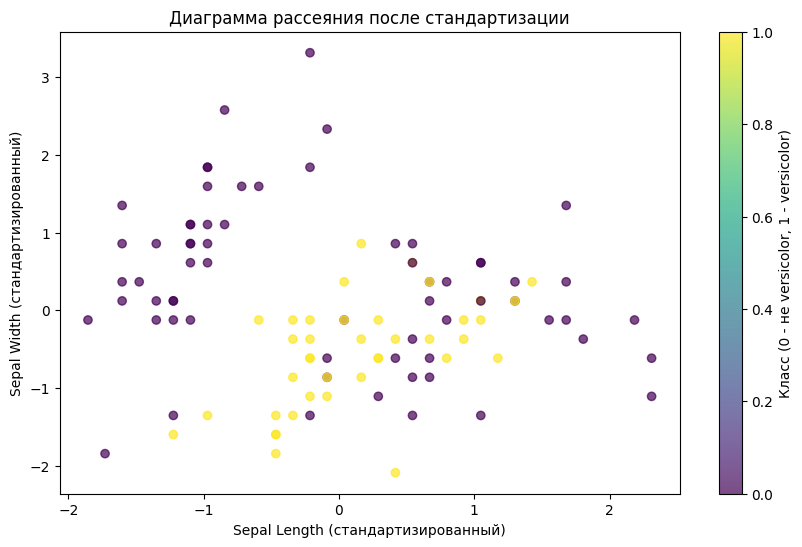

In [11]:
X = data[['sepal length (cm)', 'sepal width (cm)']].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=123)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование данных
ss = StandardScaler()
ss.fit(X_train, y_train)

X_train_ss = ss.transform(X_train)
X_test_ss = ss.transform(X_test)

# Визуализация данных после масштабирования
plt.figure(figsize=(10, 6))
plt.scatter(X_train_ss[:, 0], X_train_ss[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel('Sepal Length (стандартизированный)')
plt.ylabel('Sepal Width (стандартизированный)')
plt.title('Диаграмма рассеяния после стандартизации')
plt.colorbar(label='Класс (0 - не versicolor, 1 - versicolor)')
plt.show()

## Задание 3: Обучение и сравнение моделей

Первые 5 прогнозов KNN: [0 1 0 1 0]
Первые 5 прогнозов LogReg: [1 0 1 0 0]
Первые 5 вероятностей KNN:
[[1.  0. ]
 [0.2 0.8]
 [0.6 0.4]
 [0.  1. ]
 [1.  0. ]]
Первые 5 вероятностей LogReg:
[[0.29417961 0.70582039]
 [0.57205493 0.42794507]
 [0.46752787 0.53247213]
 [0.63769064 0.36230936]
 [0.90567108 0.09432892]]
KNN точность: 0.756
LogReg точность: 0.844


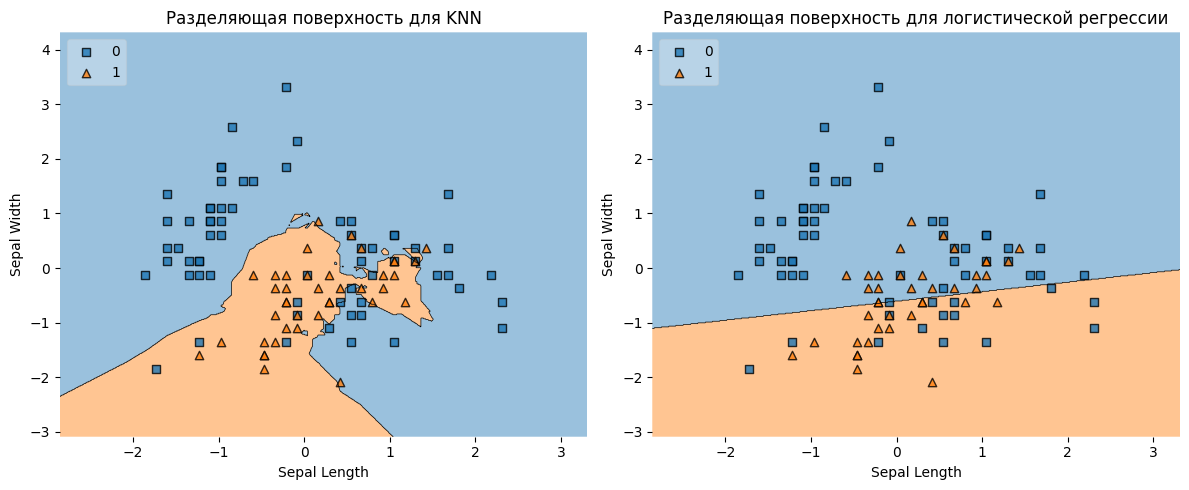

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(random_state=123)

# Обучение классификаторов
knn.fit(X_train_ss, y_train)
logreg.fit(X_train_ss, y_train)

# Прогноз метки класса
y_test_pred_knn = knn.predict(X_test_ss)
y_test_pred_logreg = logreg.predict(X_test_ss)

print("Первые 5 прогнозов KNN:", y_test_pred_knn[:5])
print("Первые 5 прогнозов LogReg:", y_test_pred_logreg[:5])

# Прогноз вероятности класса
y_test_proba_knn = knn.predict_proba(X_test_ss)
y_test_proba_logreg = logreg.predict_proba(X_test_ss)

print("Первые 5 вероятностей KNN:")
print(y_test_proba_knn[:5])
print("Первые 5 вероятностей LogReg:")
print(y_test_proba_logreg[:5])

# Оценка качества
print(f'KNN точность: {accuracy_score(y_test, y_test_pred_knn):.3f}')
print(f'LogReg точность: {accuracy_score(y_test, y_test_pred_logreg):.3f}')

# Визуализация разделяющих поверхностей
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_regions(X_train_ss, y_train, clf=knn, legend=2)
plt.title('Разделяющая поверхность для KNN')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.subplot(1, 2, 2)
plot_decision_regions(X_train_ss, y_train, clf=logreg, legend=2)
plt.title('Разделяющая поверхность для логистической регрессии')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.tight_layout()
plt.show()

## Задание 4: Логистическая регрессия с разным параметром C

Правильность при C=0.01: 0.778
Правильность при C=0.05: 0.844
Правильность при C=10: 0.844


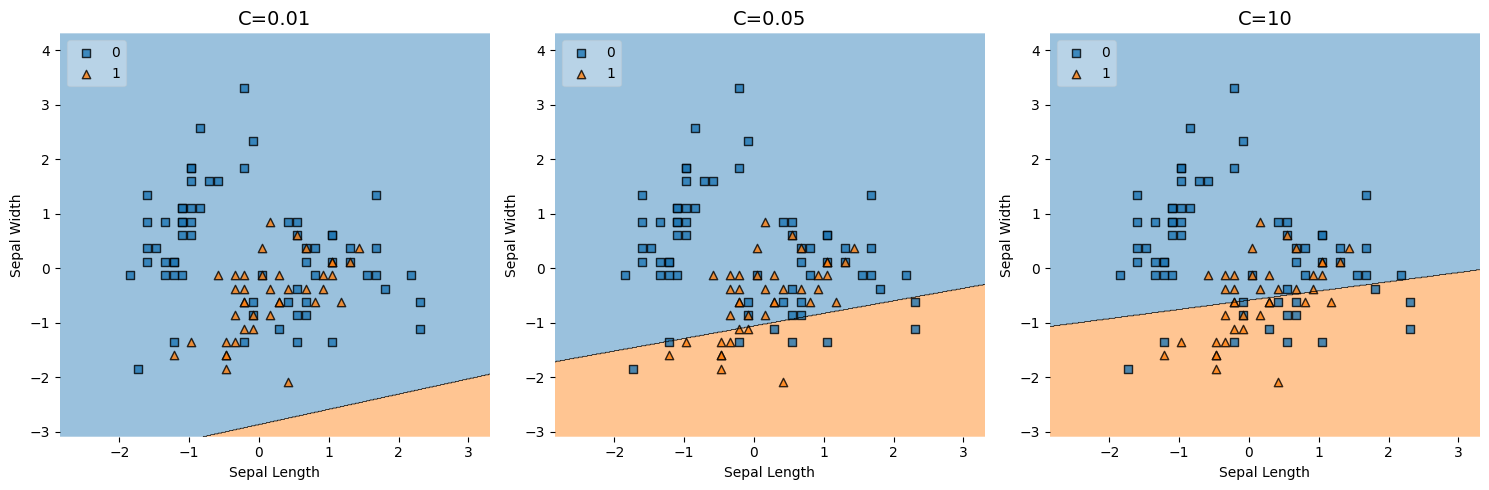

In [13]:
logreg_1 = LogisticRegression(C=0.01, random_state=123)
logreg_2 = LogisticRegression(C=0.05, random_state=123) 
logreg_3 = LogisticRegression(C=10, random_state=123)

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
pipes = [logreg_1, logreg_2, logreg_3]

for ind, clf in enumerate(pipes):
    clf.fit(X_train_ss, y_train)
    y_test_pred = clf.predict(X_test_ss)
    score = accuracy_score(y_test, y_test_pred)
    print(f"Правильность при C={clf.get_params()['C']}: {score:.3f}")
    plot_decision_regions(X_train_ss, y_train, clf=clf, legend=2, ax=axes[ind])
    axes[ind].set_title(f"C={clf.get_params()['C']}", fontsize=14)
    axes[ind].set_xlabel('Sepal Length')
    axes[ind].set_ylabel('Sepal Width')

plt.tight_layout()
plt.show()

## Задание 5: KNN с разным количеством соседей

Правильность при n_neighbors=1: 0.822
Правильность при n_neighbors=5: 0.756
Правильность при n_neighbors=50: 0.800


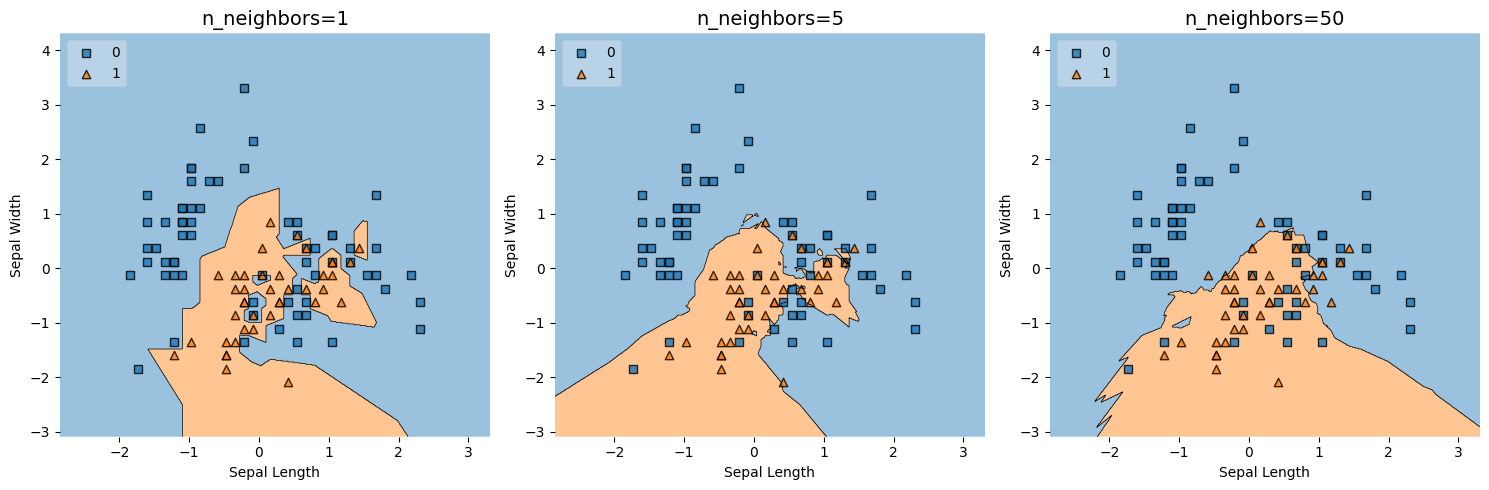

In [14]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_2 = KNeighborsClassifier(n_neighbors=5)
knn_3 = KNeighborsClassifier(n_neighbors=50)

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
pipes = [knn_1, knn_2, knn_3]

for ind, clf in enumerate(pipes):
    clf.fit(X_train_ss, y_train)
    y_test_pred = clf.predict(X_test_ss)
    score = accuracy_score(y_test, y_test_pred)
    print(f"Правильность при n_neighbors={clf.get_params()['n_neighbors']}: {score:.3f}")
    plot_decision_regions(X_train_ss, y_train, clf=clf, legend=2, ax=axes[ind])
    axes[ind].set_title(f"n_neighbors={clf.get_params()['n_neighbors']}", fontsize=14)
    axes[ind].set_xlabel('Sepal Length')
    axes[ind].set_ylabel('Sepal Width')

plt.tight_layout()
plt.show()

## Зачем мы используем StandardScaler?

In [15]:
print("""
StandardScaler используется для стандартизации признаков - приведения их к нулевому среднему и единичной дисперсии.
Это важно потому что:
1. Алгоритмы, основанные на расстояниях (как KNN) чувствительны к масштабу признаков
2. Градиентные методы (как в логистической регрессии) сходятся быстрее
3. Регуляризация равномерно влияет на все признаки

Если один признак умножить на 10^6, он будет доминировать при вычислении расстояний и весов,
что может сильно ухудшить качество моделей.
""")

# Поиск оптимального C для логистической регрессии
print("Поиск оптимального C для логистической регрессии:")
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_C = None
best_score = 0

for C in C_values:
    logreg = LogisticRegression(C=C, random_state=123)
    logreg.fit(X_train_ss, y_train)
    score = logreg.score(X_test_ss, y_test)
    print(f"C={C}: точность = {score:.3f}")
    if score > best_score:
        best_score = score
        best_C = C

print(f"Лучшее значение C: {best_C} с точностью {best_score:.3f}")

# Поиск оптимального K для KNN
print("\nПоиск оптимального K для KNN:")
k_values = range(1, 21)
best_k = None
best_score_knn = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_ss, y_train)
    score = knn.score(X_test_ss, y_test)
    print(f"K={k}: точность = {score:.3f}")
    if score > best_score_knn:
        best_score_knn = score
        best_k = k

print(f"Лучшее значение K: {best_k} с точностью {best_score_knn:.3f}")


StandardScaler используется для стандартизации признаков - приведения их к нулевому среднему и единичной дисперсии.
Это важно потому что:
1. Алгоритмы, основанные на расстояниях (как KNN) чувствительны к масштабу признаков
2. Градиентные методы (как в логистической регрессии) сходятся быстрее
3. Регуляризация равномерно влияет на все признаки

Если один признак умножить на 10^6, он будет доминировать при вычислении расстояний и весов,
что может сильно ухудшить качество моделей.

Поиск оптимального C для логистической регрессии:
C=0.001: точность = 0.778
C=0.01: точность = 0.778
C=0.1: точность = 0.867
C=1: точность = 0.844
C=10: точность = 0.844
C=100: точность = 0.844
Лучшее значение C: 0.1 с точностью 0.867

Поиск оптимального K для KNN:
K=1: точность = 0.822
K=2: точность = 0.822
K=3: точность = 0.756
K=4: точность = 0.800
K=5: точность = 0.756
K=6: точность = 0.756
K=7: точность = 0.733
K=8: точность = 0.756
K=9: точность = 0.733
K=10: точность = 0.756
K=11: точность = 0.711
K=12:

## Генерация нелинейных данных

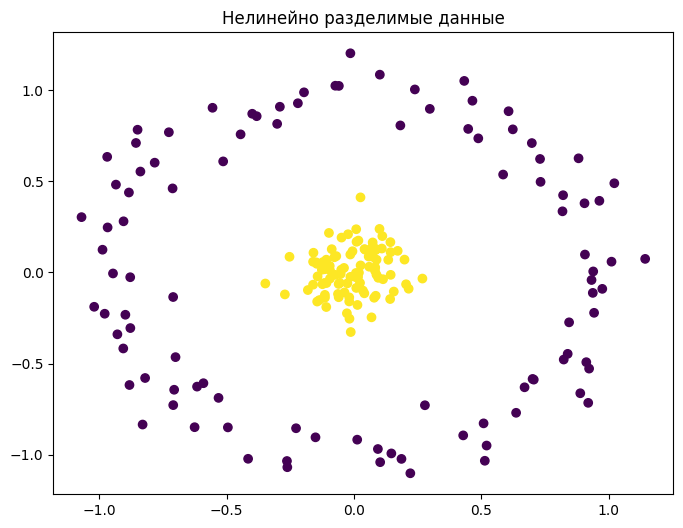

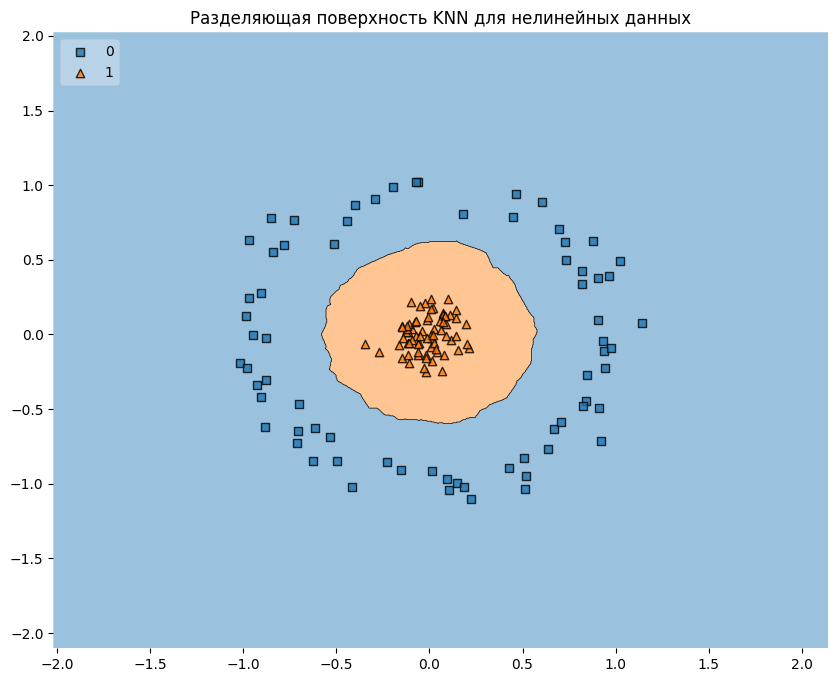

Точность KNN на исходных данных: 1.000
Точность KNN на данных с полиномиальным признаком: 1.000


In [16]:
from sklearn.datasets import make_circles

X_circle, y_circle = make_circles(n_samples=200, shuffle=True, noise=0.1, factor=0.1)

plt.figure(figsize=(8, 6))
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='viridis')
plt.title('Нелинейно разделимые данные')
plt.show()

# Разделение на обучающую и тестовую выборки
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circle, y_circle, test_size=0.3, random_state=123)

# Обучение KNN на нелинейных данных
knn_circle = KNeighborsClassifier(n_neighbors=5)
knn_circle.fit(X_train_c, y_train_c)

# Визуализация разделяющей поверхности
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train_c, y_train_c, clf=knn_circle, legend=2)
plt.title('Разделяющая поверхность KNN для нелинейных данных')
plt.show()

# Добавление полиномиального признака
X1_c = X_circle[:, 0]
X2_c = X_circle[:, 1]
X3_c = X1_c**2 + X2_c**2

X_new_c = np.c_[X1_c, X2_c, X3_c]

# Разделение расширенных данных
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new_c, y_circle, test_size=0.3, random_state=123)

# Обучение KNN на расширенных данных
knn_extended = KNeighborsClassifier(n_neighbors=5)
knn_extended.fit(X_train_new, y_train_new)

print(f"Точность KNN на исходных данных: {knn_circle.score(X_test_c, y_test_c):.3f}")
print(f"Точность KNN на данных с полиномиальным признаком: {knn_extended.score(X_test_new, y_test_new):.3f}")